In [45]:
import numpy as np
import matplotlib.pyplot as plt
from few.trajectory.inspiral import EMRIInspiral
from multispline.spline import CubicSpline

In [117]:
# Some elliptic functions for evaluating geodesic frequencies
from few.utils.elliptic import EllipK, EllipE, EllipPi

# base classes
from few.trajectory.ode.base import ODEBase


# this class defines the right-hand side of the ODE
# we define the method "evaluate_rhs" according to our derivatives
# we set the "equatorial" and "background" properties accordingly
# we also set the "flux_output_convention" property to "pex" to tell the trajectory module what
# the RHS derivatives correspond to
class Schwarzschild_Plunge(ODEBase):
    @property
    def equatorial(self):
        return True

    @property
    def background(self):
        return "Schwarzschild"

    def cache_values_and_check_bounds(self,y):
        return True

    # @property
    # def flux_output_convention(self):
    #     return "pex"

    def evaluate_rhs(self, y):
        # guard against bad integration steps
        p, e, xI = y[:3]

        pdot = (-1/(2**(3./2.))*(6/p-1)**(3./2.)*(1-2/p))/(m2/m1)
        edot = 0
        xIdot = 0
        Phi_phi_dot = np.sqrt(3./2.)*3/p**2*(1-2/p)
        Phi_theta_dot = 0
        Phi_r_dot = 0

        dydt = [pdot, edot, xIdot, Phi_phi_dot, Phi_theta_dot, Phi_r_dot]

        return dydt

In [118]:
test = Schwarzschild_Plunge()
test.add_fixed_parameters(M,mu,0)
test([5,e0,x0])

array([-0.18973666,  0.        ,  0.        ,  0.08818163,  0.        ,
        0.        ])

In [194]:
m1 = 1e6
m2 = 1e5
p0 = 5.5
e0 = 0.0
x0 = 1.0
T = 0.0002

insp = EMRIInspiral(func=Schwarzschild_Plunge)

traj = insp(m1, m2, 0.0, p0, e0, x0, T=T, dt=1.0, upsample=True)

In [195]:
t,p,e,x,Phi_phi,Phi_theta,Phi_r = traj

(0.0, 600.0)

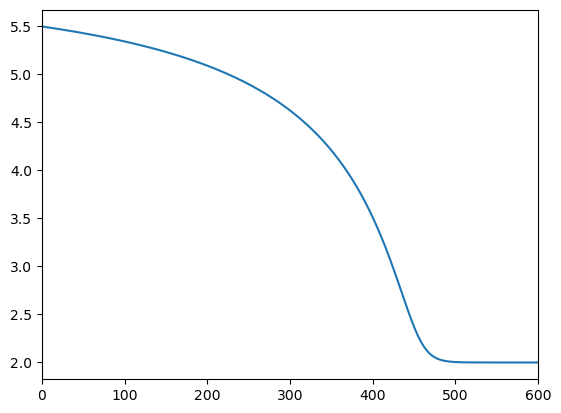

In [197]:
plt.plot(t,p)
plt.xlim(0,600)

In [198]:
data = np.loadtxt("/Users/niels/Downloads/plungeAmps-l2m2.dat")

In [199]:
ReAmpl2m2 = CubicSpline(data[:,0], data[:,1])
ImAmpl2m2 = CubicSpline(data[:,0], data[:,2])

In [200]:
def rs(r):
    return r + 2*np.log(r-2)

In [201]:
wav = (ReAmpl2m2(rs(p)) + 1j* ImAmpl2m2(rs(p)))*np.exp(-2j*Phi_phi)

/var/folders/pp/8lrdldlx72vbsqswqgflv0gm0000gn/T/ipykernel_62704/484005536.py:2: RuntimeWarning: divide by zero encountered in log
  return r + 2*np.log(r-2)
/var/folders/pp/8lrdldlx72vbsqswqgflv0gm0000gn/T/ipykernel_62704/484005536.py:2: RuntimeWarning: invalid value encountered in log
  return r + 2*np.log(r-2)
/var/folders/pp/8lrdldlx72vbsqswqgflv0gm0000gn/T/ipykernel_62704/3313609430.py:1: RuntimeWarning: invalid value encountered in multiply
  wav = (ReAmpl2m2(rs(p)) + 1j* ImAmpl2m2(rs(p)))*np.exp(-2j*Phi_phi)


(-0.75, 0.75)

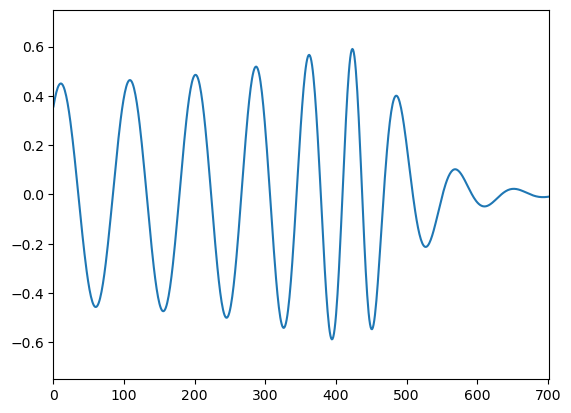

In [213]:
plt.plot(t,np.real(wav))
plt.xlim(0,702)
plt.ylim(-0.75,0.75)